<a href="https://colab.research.google.com/github/Teixeiras7/Linguagens-de-Programa-o/blob/main/Exercicio1.4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")
np.random.seed(101)

# Gerando dados fictícios de clientes de um e-commerce
n = 200
categorias = ['Eletrônicos', 'Vestuário', 'Casa e Decoração', 'Livros']

dados = {
    'ID_Cliente': np.random.randint(1000, 1050, size=n),
    'Categoria': np.random.choice(categorias, size=n),
    'Valor_Gasto': np.random.normal(loc=250, scale=80, size=n).round(2),
    'Avaliacao_Compra': np.random.choice([1, 2, 3, 4, 5, np.nan], size=n, p=[0.1, 0.1, 0.2, 0.3, 0.2, 0.1]),
    'Idade_Cliente': np.random.randint(18, 65, size=n)
}

df_ecommerce = pd.DataFrame(dados)

# Inserindo algumas linhas duplicadas intencionalmente
df_ecommerce = pd.concat([df_ecommerce, df_ecommerce.iloc[:10]], ignore_index=True)

print("Dataset gerado com sucesso!")
print(f"Total de linhas no dataset: {len(df_ecommerce)}")
df_ecommerce.head()

Dataset gerado com sucesso!
Total de linhas no dataset: 210


,ID_Cliente,Categoria,Valor_Gasto,Avaliacao_Compra,Idade_Cliente
0,1031,Vestuário,236.62,NaN,33
1,1011,Eletrônicos,190.28,4.0,47
2,1017,Eletrônicos,336.59,2.0,35
3,1006,Eletrônicos,307.38,5.0,52
4,1023,Vestuário,170.69,4.0,42


In [15]:
print('--- Tarefa 1: Limpeza e Preparação dos Dados ---')

# 1. Verifique quantas linhas duplicadas existem no DataFrame e remova-as.
print(f"Número de linhas duplicadas antes da remoção: {df_ecommerce.duplicated().sum()}")

df_ecommerce.drop_duplicates(inplace=True)

print(f"Número de linhas após a remoção de duplicatas: {len(df_ecommerce)}")


# 2. Identifique quais colunas possuem valores nulos (NaN).
print("\nValores nulos por coluna:")
print(df_ecommerce.isnull().sum())


# 3. Preencha os valores nulos da coluna 'Avaliacao_Compra'
#    com a mediana dessa mesma coluna.
median_avaliacao = df_ecommerce['Avaliacao_Compra'].median()

df_ecommerce['Avaliacao_Compra'] = (
    df_ecommerce['Avaliacao_Compra'].fillna(median_avaliacao)
)

print("\nValores nulos após o preenchimento da Avaliacao_Compra:")
print(df_ecommerce.isnull().sum())

print(
    f"Mediana usada para preencher NaN em "
    f"'Avaliacao_Compra': {median_avaliacao}"
)

--- Tarefa 1: Limpeza e Preparação dos Dados ---
Número de linhas duplicadas antes da remoção: 0
Número de linhas após a remoção de duplicatas: 200

Valores nulos por coluna:
ID_Cliente          0
Categoria           0
Valor_Gasto         0
Avaliacao_Compra    0
Idade_Cliente       0
dtype: int64

Valores nulos após o preenchimento da Avaliacao_Compra:
ID_Cliente          0
Categoria           0
Valor_Gasto         0
Avaliacao_Compra    0
Idade_Cliente       0
dtype: int64
Mediana usada para preencher NaN em 'Avaliacao_Compra': 4.0


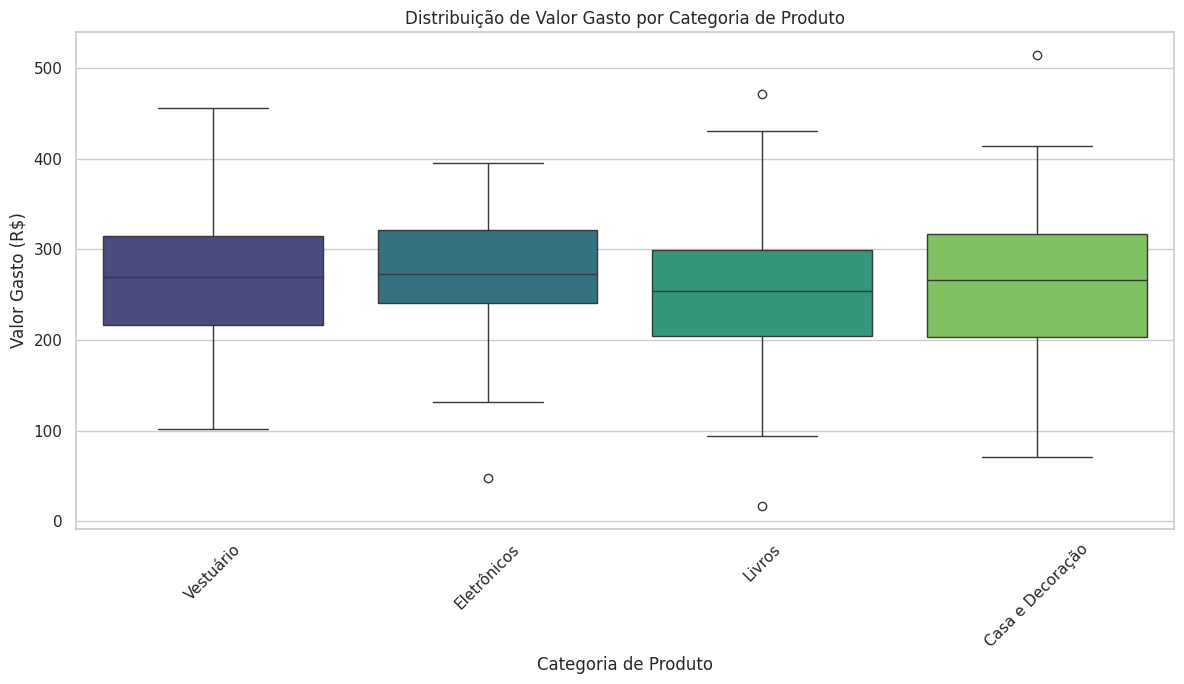


Variação do Valor_Gasto por categoria:
                     min     max        std
Categoria                                  
Casa e Decoração   70.63  514.29  88.942519
Livros             16.89  471.64  81.135752
Vestuário         102.12  455.23  77.837054
Eletrônicos        47.76  395.03  71.303618

A categoria com maior variação, considerando o desvio padrão, é 'Casa e Decoração'.


In [18]:
# 1. Crie um gráfico de Boxplot para comparar a distribuição
# de Valor_Gasto entre as diferentes Categorias de produtos.

plt.figure(figsize=(12, 7))

sns.boxplot(
    x='Categoria',
    y='Valor_Gasto',
    data=df_ecommerce,
    hue='Categoria',
    palette='viridis',
    legend=False
)

plt.title('Distribuição de Valor Gasto por Categoria de Produto')
plt.xlabel('Categoria de Produto')
plt.ylabel('Valor Gasto (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 2. Identifique a categoria com maior variação.
variacao_por_categoria = (
    df_ecommerce.groupby('Categoria')['Valor_Gasto']
    .agg(['min', 'max', 'std'])
    .sort_values('std', ascending=False)
)

print("\nVariação do Valor_Gasto por categoria:")
print(variacao_por_categoria)

print(
    f"\nA categoria com maior variação, considerando o desvio padrão, "
    f"é '{variacao_por_categoria.index[0]}'."
)



--- Tarefa 3: Distribuição e Correlação ---


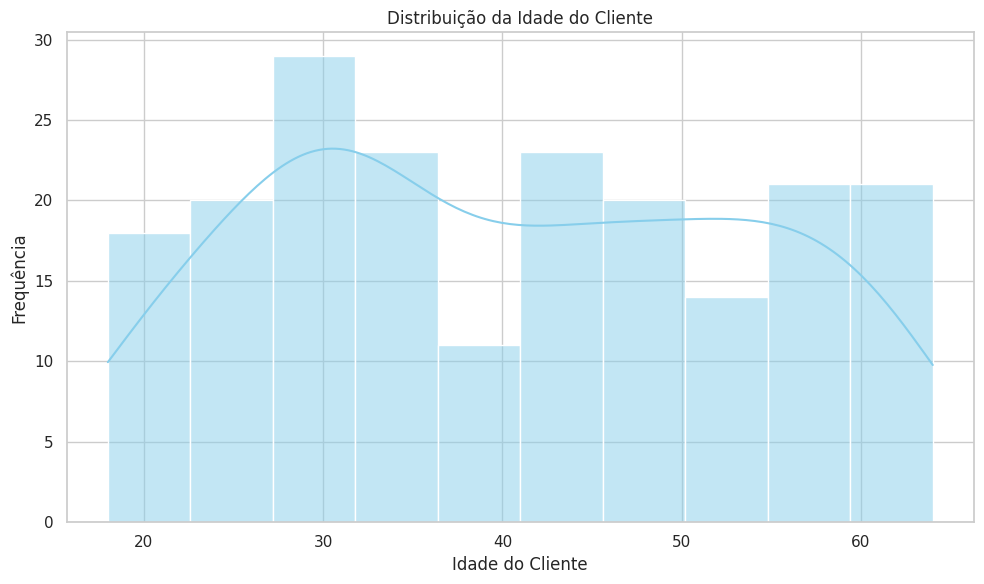

In [19]:
print('\n--- Tarefa 3: Distribuição e Correlação ---')

# 1. Crie um gráfico de Histograma com curva de densidade (`sns.histplot` com `kde=True`) para visualizar a distribuição da `Idade_Cliente`.
# 2. Adicione título e rótulos adequados aos eixos do gráfico.
plt.figure(figsize=(10, 6))
sns.histplot(df_ecommerce['Idade_Cliente'], kde=True, bins=10, color='skyblue')
plt.title('Distribuição da Idade do Cliente')
plt.xlabel('Idade do Cliente')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()